## Title: Cars24 Price Prediction

# Objective
To develop an end-to-end machine learning system that predicts used car prices and provides actionable market intelligence insights to support data-driven decision-making in the automobile resale industry

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
df = pd.read_csv(r"c:\Users\sangu\OneDrive\Desktop\Excler Project\cars24_data.csv")
df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


# EDA

In [3]:
df.shape

(6437, 19)

In [4]:
df.columns

Index(['name', 'make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'url', 'createdDate'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   name               6437 non-null   str  
 1   make               6437 non-null   str  
 2   model              6437 non-null   str  
 3   city               6437 non-null   str  
 4   year               6437 non-null   int64
 5   fueltype           6437 non-null   str  
 6   kilometerdriven    6437 non-null   int64
 7   ownernumber        6437 non-null   int64
 8   transmission       6061 non-null   str  
 9   bodytype           6062 non-null   str  
 10  storename          6437 non-null   str  
 11  isc24assured       6437 non-null   bool 
 12  registrationcity   6437 non-null   str  
 13  registrationstate  6437 non-null   str  
 14  benefits           6437 non-null   int64
 15  discountprice      6437 non-null   int64
 16  price              6437 non-null   int64
 17  url                6437 n

In [6]:
df['car_age'] = 2026 - df['year']

FInding null values

In [7]:
df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
car_age                0
dtype: int64

In [8]:
df.describe()

,year,kilometerdriven,ownernumber,benefits,discountprice,price,car_age
count,6437.000000,6437.000000,6437.000000,6437.000000,6437.000000,6.437000e+03,6437.000000
mean,2017.636166,41568.066335,1.235669,12079.200559,23500.592512,6.781378e+05,8.363834
std,2.656825,26187.115364,0.454501,2458.162316,41579.296564,3.450395e+05,2.656825
min,2008.000000,64.000000,1.000000,9688.000000,-155500.000000,1.340000e+05,4.000000
25%,2016.000000,20580.000000,1.000000,9688.000000,-100.000000,4.390000e+05,6.000000
50%,2018.000000,38177.000000,1.000000,12542.000000,10600.000000,5.880000e+05,8.000000
75%,2020.000000,59333.000000,1.000000,13898.000000,37000.000000,8.290000e+05,10.000000
max,2022.000000,455601.000000,3.000000,19407.000000,388300.000000,3.048000e+06,18.000000


Handling null values

In [9]:
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])
df['bodytype'] = df['bodytype'].fillna(df['bodytype'].mode()[0])

Dropping unwanted columns


In [10]:
df = df.drop(['url'], axis=1)

In [11]:
df = df.drop(['storename'], axis=1)

In [12]:
df['createdDate'] = pd.to_datetime(df['createdDate'])
df['car_age_posted'] = 2026 - df['createdDate'].dt.year

In [13]:
df = df.drop(['createdDate'], axis=1)

VISUAL EDA INSIGHTS 

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Premium theme
sns.set_theme(style="whitegrid", context="talk")

# Bigger + consistent figures
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

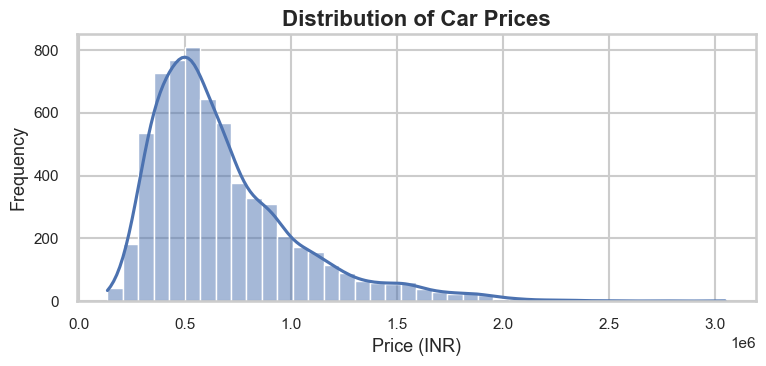

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True, color='#4C72B0', bins=40)
plt.title("Distribution of Car Prices", fontweight='bold')
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

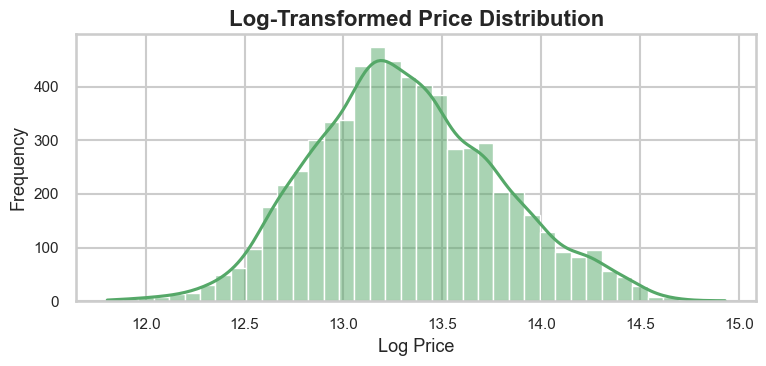

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['price']), kde=True, color='#55A868', bins=40)
plt.title("Log-Transformed Price Distribution", fontweight='bold')
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This indicates that most used cars are affordable, while luxury cars create a long tail.
 Log transformation may improve model performance.

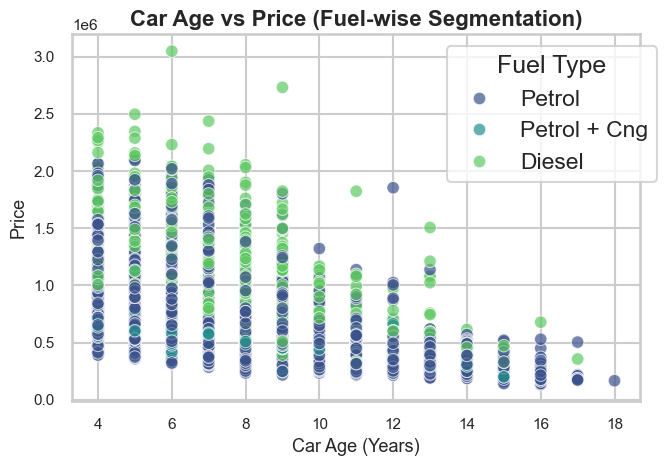

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='car_age',
    y='price',
    data=df,
    hue='fueltype',
    palette='viridis',
    alpha=0.7
)
plt.title("Car Age vs Price (Fuel-wise Segmentation)", fontweight='bold')
plt.xlabel("Car Age (Years)")
plt.ylabel("Price")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Car depreciation is a strong factor affecting resale value.
 car_age is a highly important feature for prediction.

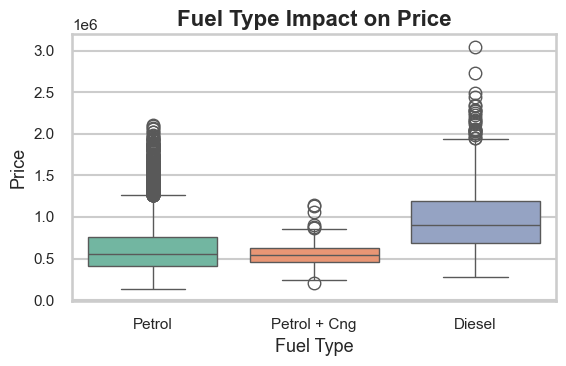

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='fueltype',
    y='price',
    data=df,
    palette='Set2'
)
plt.title("Fuel Type Impact on Price", fontweight='bold')
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

Fuel type significantly influences price due to performance, mileage, and demand.
 Important categorical feature.

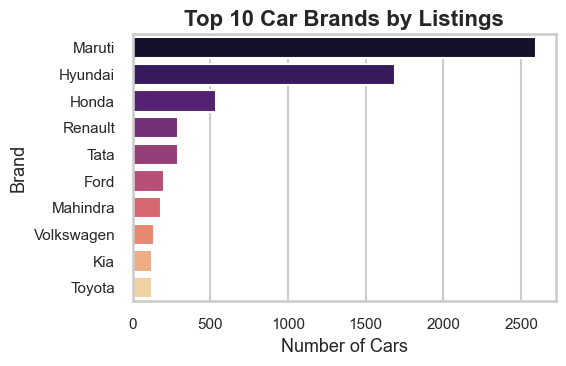

In [19]:
plt.figure(figsize=(6,4))
top_brands = df['make'].value_counts().head(10)
sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette='magma'
)
plt.title("Top 10 Car Brands by Listings", fontweight='bold')
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Dataset is skewed toward mass-market brands
 Model may bias toward common brands

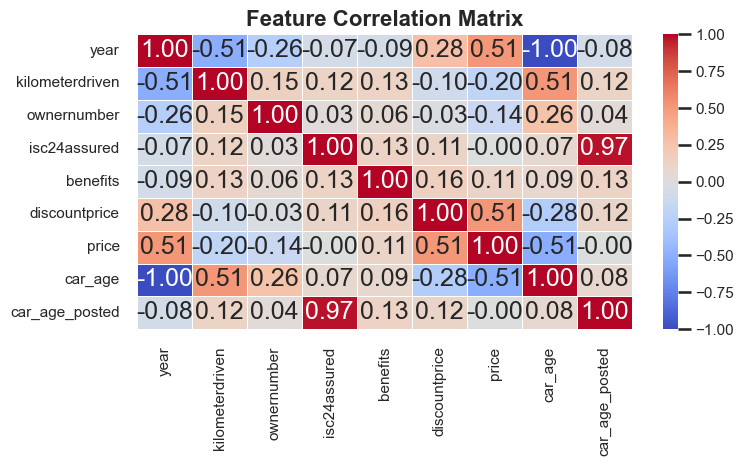

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

No single feature dominates — multiple factors contribute

The resale price of a car is influenced by a combination of age, usage, brand, fuel type, and ownership history.
Depreciation and brand positioning are the strongest drivers of pricing in the used car market.

Encoding

In [21]:
df_cleaned=df.copy()
df_cleaned.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,car_age,car_age_posted
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,False,Kozhikode,Kerala,13898,47399,607000,9,4
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,False,Mumbai,Maharashtra,12542,2099,326000,10,4
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,False,Lucknow,Uttar Pradesh,13898,26000,640000,7,4
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,False,Bengaluru,Karnataka,9688,143700,1354000,6,4
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,False,Barrackpore,West Bengal,13898,22800,676000,9,4


In [22]:
from src.data_preprocessing import preprocess_data
df_processed = preprocess_data(df_cleaned)
df_processed.head()

,year,kilometerdriven,ownernumber,isc24assured,benefits,discountprice,price,car_age,car_age_posted,fueltype_Petrol,...,city_Others,city_Pune,registrationstate_Gujarat,registrationstate_Haryana,registrationstate_Karnataka,registrationstate_Maharashtra,registrationstate_Others,registrationstate_Tamil Nadu,registrationstate_Telangana,registrationstate_Uttar Pradesh
0,2017,35939,2,0,13898,47399,607000,9,4,True,...,True,False,False,False,False,False,True,False,False,False
1,2016,6180,1,0,12542,2099,326000,10,4,False,...,False,False,False,False,False,True,False,False,False,False
2,2019,46808,1,0,13898,26000,640000,7,4,False,...,True,False,False,False,False,False,False,False,False,True
3,2020,26045,1,0,9688,143700,1354000,6,4,False,...,False,False,False,False,True,False,False,False,False,False
4,2017,53056,1,0,13898,22800,676000,9,4,True,...,False,False,False,False,False,False,True,False,False,False


In [23]:
df_processed = df_processed.astype(int)
df_processed.head()

,year,kilometerdriven,ownernumber,isc24assured,benefits,discountprice,price,car_age,car_age_posted,fueltype_Petrol,...,city_Others,city_Pune,registrationstate_Gujarat,registrationstate_Haryana,registrationstate_Karnataka,registrationstate_Maharashtra,registrationstate_Others,registrationstate_Tamil Nadu,registrationstate_Telangana,registrationstate_Uttar Pradesh
0,2017,35939,2,0,13898,47399,607000,9,4,1,...,1,0,0,0,0,0,1,0,0,0
1,2016,6180,1,0,12542,2099,326000,10,4,0,...,0,0,0,0,0,1,0,0,0,0
2,2019,46808,1,0,13898,26000,640000,7,4,0,...,1,0,0,0,0,0,0,0,0,1
3,2020,26045,1,0,9688,143700,1354000,6,4,0,...,0,0,0,0,1,0,0,0,0,0
4,2017,53056,1,0,13898,22800,676000,9,4,1,...,0,0,0,0,0,0,1,0,0,0


In [24]:
#df_final = df_processed.copy()

In [25]:
from src.feature_engineering import feature_engineering

df_final = feature_engineering(df_processed)

df_final.head()


🔹 Top correlated features with price:
price                    1.000000
discountprice            0.512306
year                     0.512105
bodytype_SUV             0.479838
make_Others              0.362356
make_Mahindra            0.236146
bodytype_Luxury SUV      0.222635
make_Tata                0.162868
bodytype_Luxury Sedan    0.123933
benefits                 0.111519
Name: price, dtype: float64


,year,kilometerdriven,ownernumber,isc24assured,benefits,discountprice,price,car_age,car_age_posted,fueltype_Petrol,...,registrationstate_Gujarat,registrationstate_Haryana,registrationstate_Karnataka,registrationstate_Maharashtra,registrationstate_Others,registrationstate_Tamil Nadu,registrationstate_Telangana,registrationstate_Uttar Pradesh,km_per_year,log_km
0,2017,35939,2,0,13898,47399,607000,8,4,1,...,0,0,0,0,1,0,0,0,3993.222222,10.489606
1,2016,6180,1,0,12542,2099,326000,9,4,0,...,0,0,0,1,0,0,0,0,618.000000,8.729235
2,2019,46808,1,0,13898,26000,640000,6,4,0,...,0,0,0,0,0,0,0,1,6686.857143,10.753831
3,2020,26045,1,0,9688,143700,1354000,5,4,0,...,0,0,1,0,0,0,0,0,4340.833333,10.167619
4,2017,53056,1,0,13898,22800,676000,8,4,1,...,0,0,0,0,1,0,0,0,5895.111111,10.879122


In [26]:
df_final.duplicated().sum()

np.int64(0)

In [27]:
df_final = df_final.drop(columns=['discountprice', 'benefits'], errors='ignore')
df_final.drop_duplicates().shape
df_final.shape

(6420, 43)

In [28]:
from src.train_model import train_model

results, models = train_model(df_final)

results


🔹 Training Linear Regression...

🔹 Training Ridge Regression...

🔹 Training Lasso Regression...

🔹 Training Random Forest...

🔹 Training XGBoost...


,Model,R2 Score,RMSE,MAE,CV Mean,CV Std
4,XGBoost,0.7831,162210.57,114538.94,0.7822,0.0076
3,Random Forest,0.7736,165723.00,113236.00,0.7674,0.0119
0,Linear Regression,0.6821,196368.80,139340.71,0.6875,0.0176
2,Lasso Regression,0.6821,196368.79,139340.70,0.6875,0.0176
1,Ridge Regression,0.6821,196368.87,139339.61,0.6875,0.0176


In [29]:
model = models['XGBoost']

In [30]:
from sklearn.model_selection import train_test_split

X = df_final.drop('price', axis=1)
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
import numpy as np

y_test_shuffled = y_test.sample(frac=1, random_state=42)

print("Original R2 :", model.score(X_test, y_test))
print("Shuffled R2:", model.score(X_test, y_test_shuffled))

Original R2 : 0.78305983543396
Shuffled R2: -0.8278436660766602


In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", scores)
print("Mean CV:", scores.mean())

CV Scores: [0.76149529 0.78391069 0.78601861 0.77881813 0.76586163]
Mean CV: 0.7752208709716797


In [33]:
from src.tune_model import tune_xgboost

best_model = tune_xgboost(df_final)

Fitting 3 folds for each of 25 candidates, totalling 75 fits

🔥 Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}

✅ Tuned Model R2: 0.7829


In [34]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [35]:
from src.visualization import plot_all

plot_all(results, models, df_final)